In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Set global style
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

np.random.seed(42)
n = 300

df = pd.DataFrame({
    'Age':        np.random.randint(22, 60, n),
    'Salary':     np.random.normal(70000, 20000, n).clip(20000, 150000),
    'Experience': np.random.randint(0, 30, n),
    'Score':      np.random.normal(72, 12, n).clip(30, 100),
    'Department': np.random.choice(['HR', 'Tech', 'Sales', 'Finance'], n,
                                    p=[0.2, 0.4, 0.25, 0.15]),
    'Gender':     np.random.choice(['Male', 'Female'], n, p=[0.55, 0.45]),
    'Promoted':   np.random.choice([0, 1], n, p=[0.6, 0.4])
})

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDescribe:\n", df.describe().round(2))

Shape: (300, 7)

Head:
    Age         Salary  Experience      Score Department  Gender  Promoted
0   50   49490.002606          12  91.118240       Tech    Male         0
1   36   46339.207773          19  65.865412      Sales    Male         1
2   29   78995.480770          24  60.124742         HR  Female         0
3   42  105578.486878           3  70.490557    Finance  Female         0
4   40   56661.132501           9  72.668699    Finance  Female         1

Describe:
           Age     Salary  Experience   Score  Promoted
count  300.00     300.00      300.00  300.00    300.00
mean    41.19   70340.61       13.15   72.82      0.41
std     11.28   20211.44        8.91   11.57      0.49
min     22.00   20000.00        0.00   39.64      0.00
25%     30.00   56586.35        5.00   65.36      0.00
50%     43.00   69880.36       12.00   72.35      0.00
75%     51.00   81930.12       21.00   80.23      1.00
max     59.00  135079.70       29.00  100.00      1.00


In [9]:
print('Head:')
df.head(20)

Head:


,Age,Salary,Experience,Score,Department,Gender,Promoted
0,50,49490.002606,12,91.118240,Tech,Male,0
1,36,46339.207773,19,65.865412,Sales,Male,1
2,29,78995.480770,24,60.124742,HR,Female,0
3,42,105578.486878,3,70.490557,Finance,Female,0
4,40,56661.132501,9,72.668699,Finance,Female,1
5,44,36163.634875,2,85.130298,Finance,Male,0
6,32,83135.946623,8,51.690424,Sales,Male,0
7,32,41281.983613,12,90.354604,HR,Female,0
8,45,46334.687571,17,70.103905,Sales,Male,1
9,57,79899.913084,14,66.877427,HR,Male,1


#Hist Plot

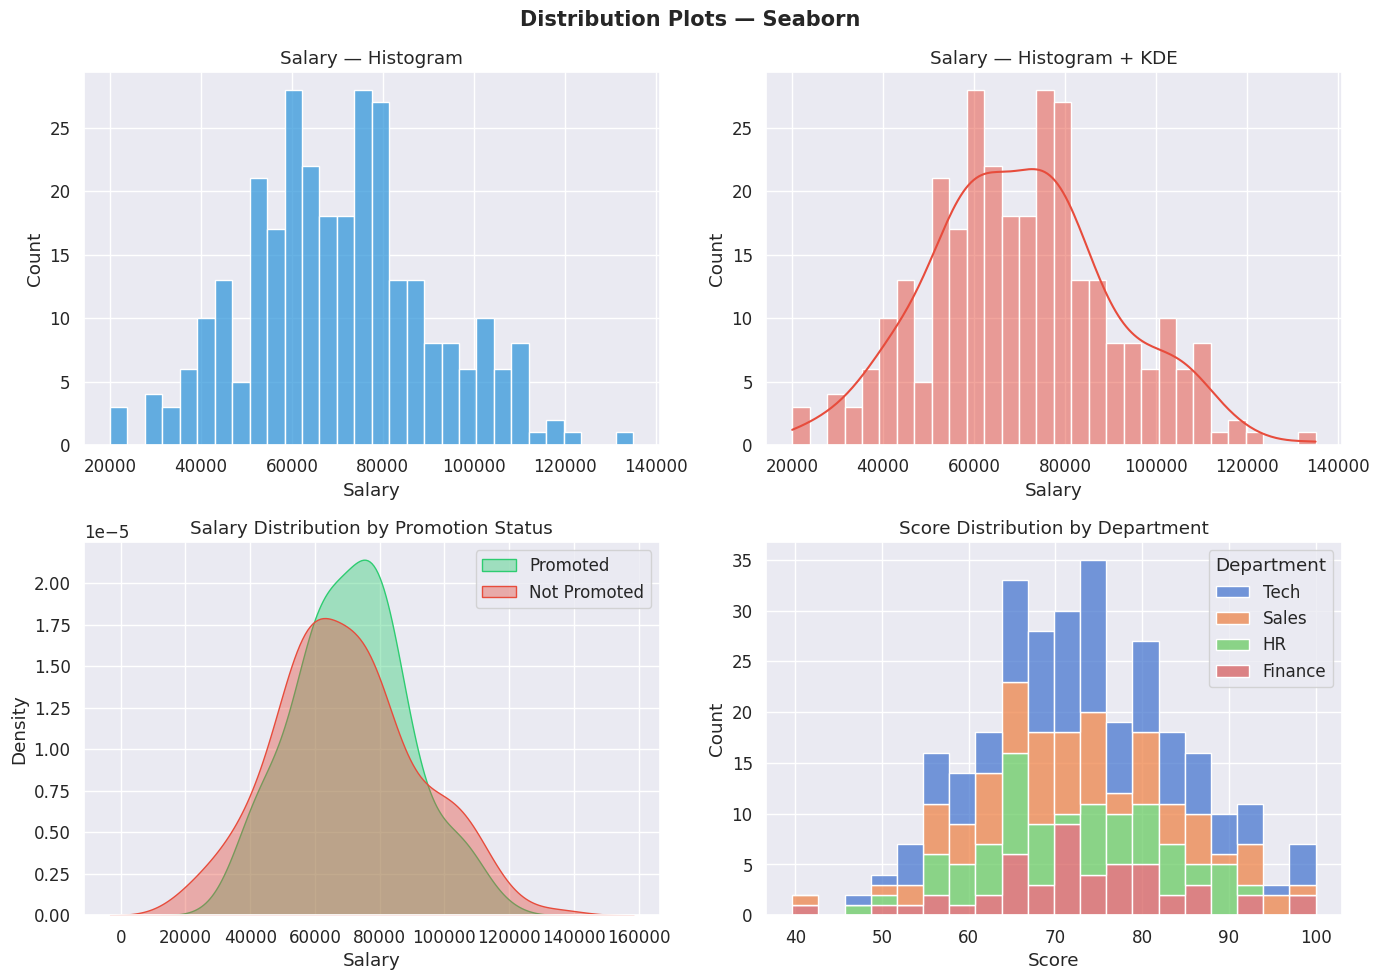

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution Plots — Seaborn', fontsize=15, fontweight='bold')

# Histogram only
sns.histplot(df['Salary'], bins=30, color='#3498db', ax=axes[0, 0])
axes[0, 0].set_title('Salary — Histogram')

# Histogram + KDE curve
sns.histplot(df['Salary'], bins=30, kde=True, color='#e74c3c', ax=axes[0, 1])
axes[0, 1].set_title('Salary — Histogram + KDE')

# KDE only — compare two groups
sns.kdeplot(df[df['Promoted'] == 1]['Salary'], color='#2ecc71',
            fill=True, alpha=0.4, label='Promoted', ax=axes[1, 0])
sns.kdeplot(df[df['Promoted'] == 0]['Salary'], color='#e74c3c',
            fill=True, alpha=0.4, label='Not Promoted', ax=axes[1, 0])
axes[1, 0].set_title('Salary Distribution by Promotion Status')
axes[1, 0].legend()

# histplot grouped by hue
sns.histplot(df, x='Score', hue='Department', bins=20,
             multiple='stack', ax=axes[1, 1])
axes[1, 1].set_title('Score Distribution by Department')

plt.tight_layout()
plt.savefig('seaborn_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_19819/543297581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Salary',
/tmp/ipykernel_19819/543297581.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Department', y='Score',


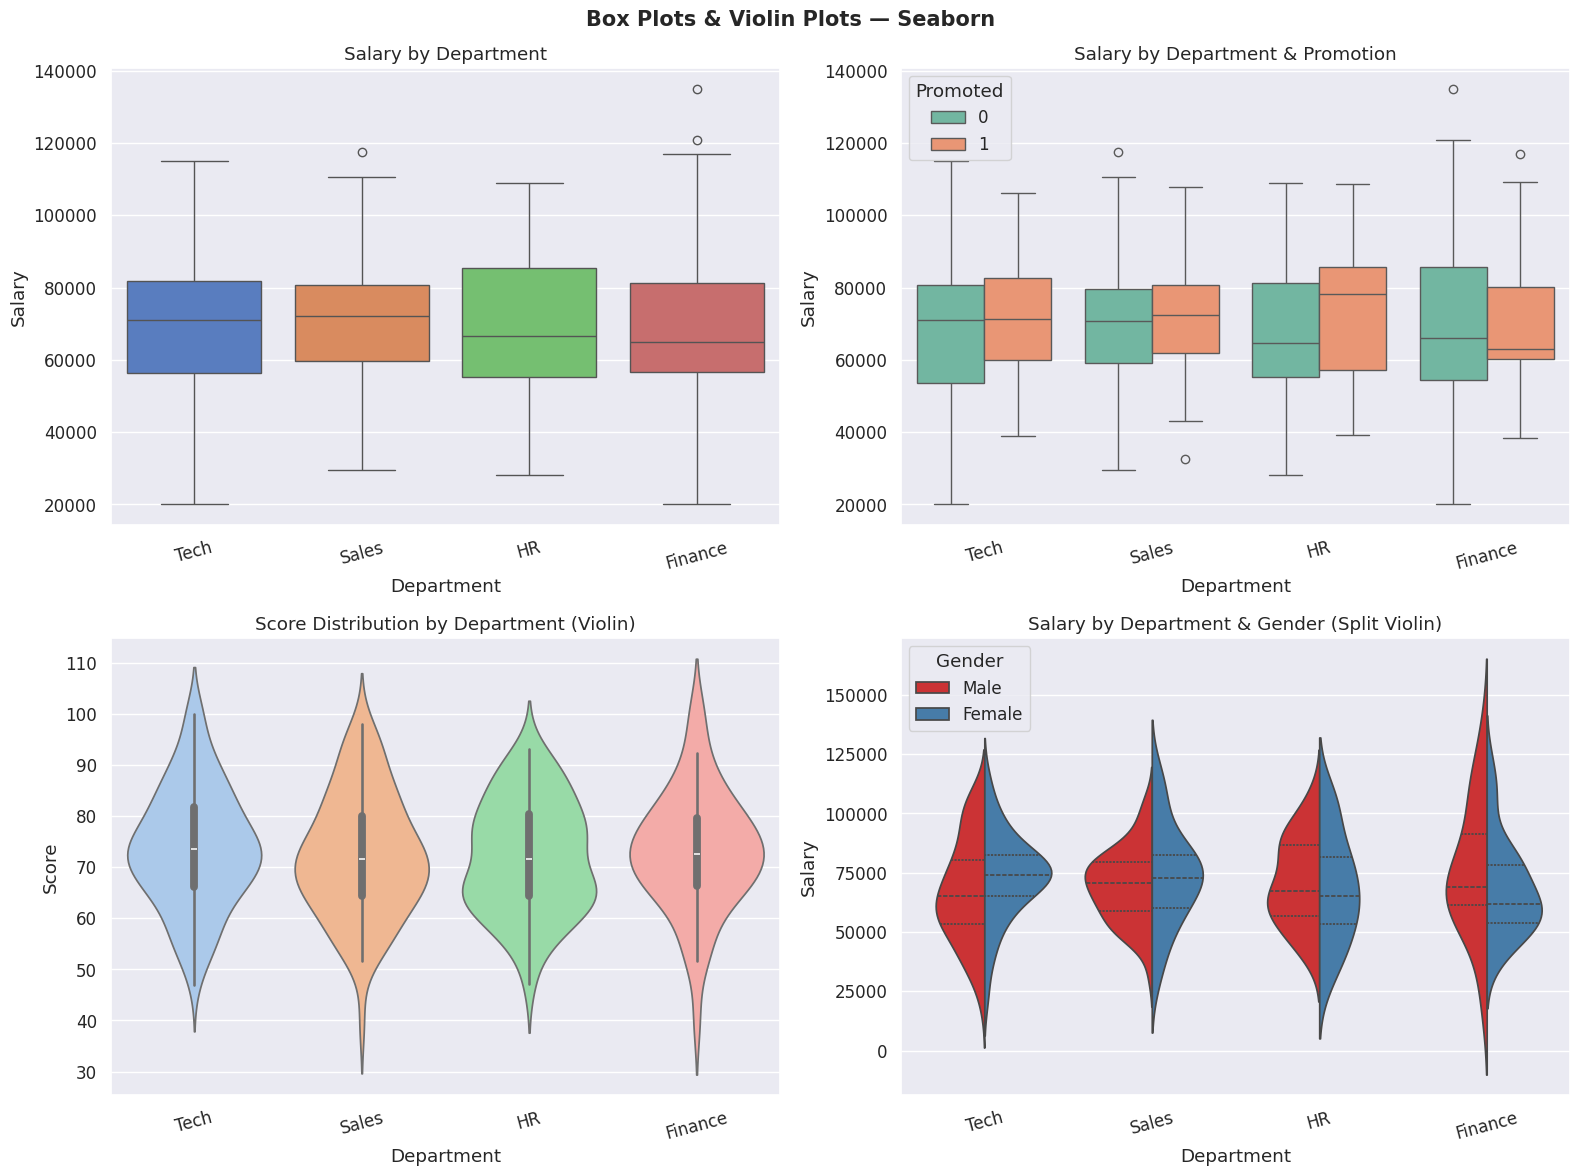

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Box Plots & Violin Plots — Seaborn', fontsize=15, fontweight='bold')

# Basic boxplot
sns.boxplot(data=df, x='Department', y='Salary',
            palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('Salary by Department')
axes[0, 0].tick_params(axis='x', rotation=15)

# Boxplot with hue
sns.boxplot(data=df, x='Department', y='Salary',
            hue='Promoted', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Salary by Department & Promotion')
axes[0, 1].tick_params(axis='x', rotation=15)

# Violin plot — shows distribution shape + box plot
sns.violinplot(data=df, x='Department', y='Score',
               palette='pastel', inner='box', ax=axes[1, 0])
axes[1, 0].set_title('Score Distribution by Department (Violin)')
axes[1, 0].tick_params(axis='x', rotation=15)

# Violin split by gender
sns.violinplot(data=df, x='Department', y='Salary',
               hue='Gender', split=True,
               palette='Set1', inner='quart', ax=axes[1, 1])
axes[1, 1].set_title('Salary by Department & Gender (Split Violin)')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('seaborn_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

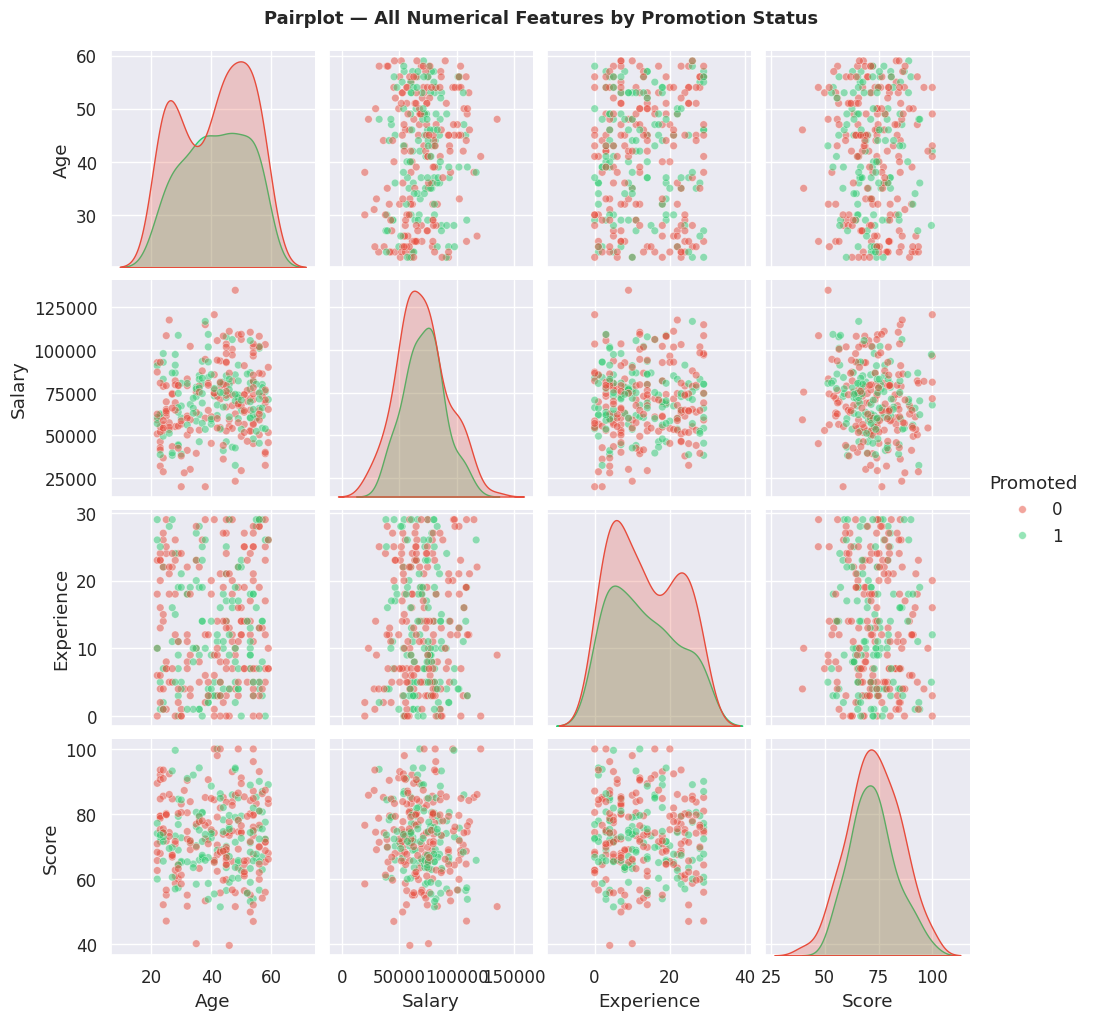

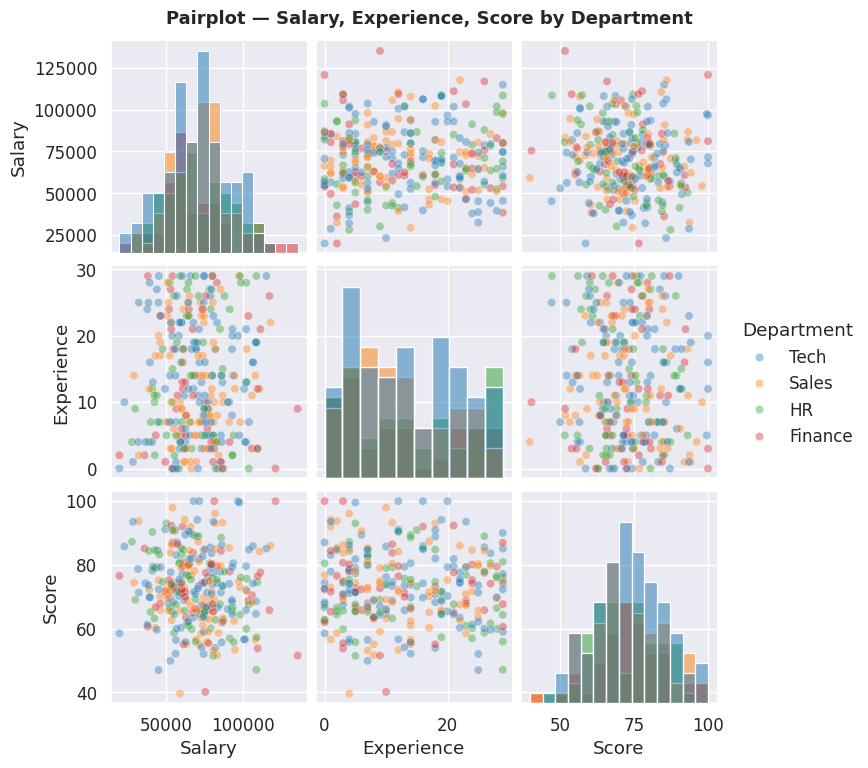

In [13]:
# Pairplot shows pairwise relationships between all numerical features
# Diagonal shows distribution of each feature
# Off-diagonal shows scatter plots between pairs

# Basic pairplot
pair = sns.pairplot(df[['Age', 'Salary', 'Experience', 'Score', 'Promoted']],
                    hue='Promoted', palette={0: '#e74c3c', 1: '#2ecc71'},
                    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
pair.fig.suptitle('Pairplot — All Numerical Features by Promotion Status',
                   y=1.02, fontsize=13, fontweight='bold')
plt.savefig('seaborn_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Focused pairplot — subset of features
pair2 = sns.pairplot(df[['Salary', 'Experience', 'Score', 'Department']],
                     hue='Department', palette='tab10',
                     diag_kind='hist', plot_kws={'alpha': 0.4})
pair2.fig.suptitle('Pairplot — Salary, Experience, Score by Department',
                    y=1.02, fontsize=13, fontweight='bold')
plt.savefig('seaborn_pairplot_dept.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Matrix:
               Age  Salary  Experience  Score  Promoted
Age         1.000   0.143       0.039 -0.031     0.021
Salary      0.143   1.000       0.040 -0.106     0.040
Experience  0.039   0.040       1.000 -0.051    -0.026
Score      -0.031  -0.106      -0.051  1.000    -0.023
Promoted    0.021   0.040      -0.026 -0.023     1.000


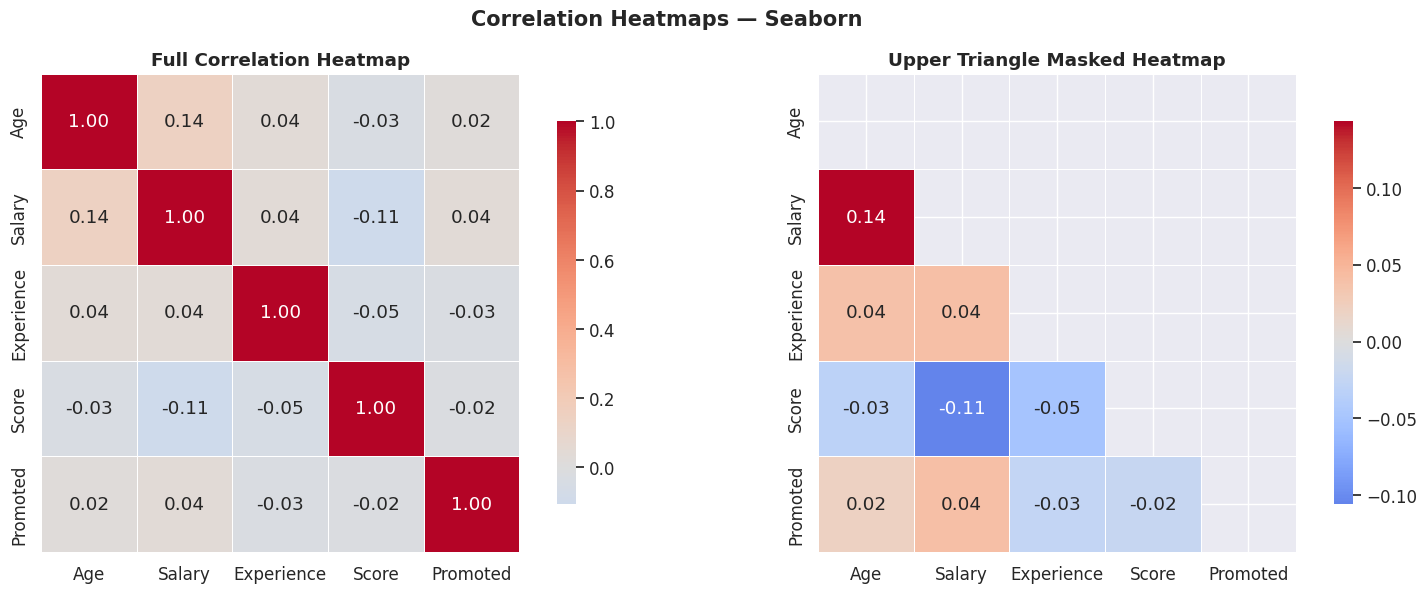


Top correlations with Promoted:
Salary        0.040453
Age           0.020633
Score        -0.022817
Experience   -0.026469
Name: Promoted, dtype: float64

Interpretation guide:
  |r| > 0.7  → Strong correlation
  |r| 0.4–0.7 → Moderate correlation
  |r| < 0.4  → Weak correlation
  r > 0      → Positive (both increase together)
  r < 0      → Negative (one increases, other decreases)



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Heatmaps — Seaborn', fontsize=15, fontweight='bold')

# Correlation matrix
corr = df[['Age', 'Salary', 'Experience', 'Score', 'Promoted']].corr()
print("Correlation Matrix:\n", corr.round(3))

# Full heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            ax=axes[0], square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Full Correlation Heatmap', fontweight='bold')

# Upper triangle only (cleaner)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            linecolor='white', ax=axes[1], square=True,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Upper Triangle Masked Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('seaborn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpret correlations
print("\nTop correlations with Promoted:")
print(corr['Promoted'].drop('Promoted').sort_values(ascending=False))
print("""
Interpretation guide:
  |r| > 0.7  → Strong correlation
  |r| 0.4–0.7 → Moderate correlation
  |r| < 0.4  → Weak correlation
  r > 0      → Positive (both increase together)
  r < 0      → Negative (one increases, other decreases)
""")

/tmp/ipykernel_19819/733952934.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_netflix, x='type', y='duration_int',


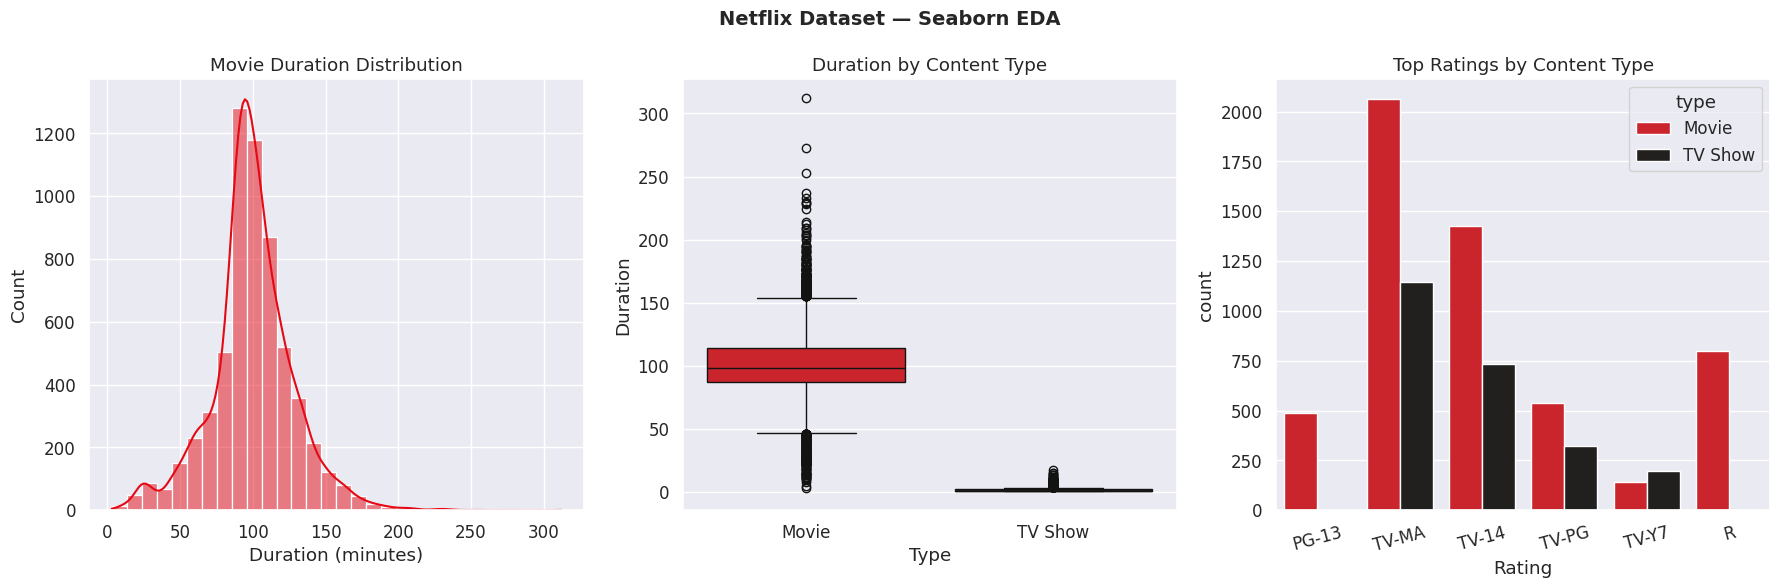

In [15]:
df_netflix = pd.read_csv('netflix_titles.csv')
df_netflix['duration_int'] = df_netflix['duration'].str.extract(r'(\d+)').astype(float)
df_netflix = df_netflix.dropna(subset=['rating', 'duration_int', 'type'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Netflix Dataset — Seaborn EDA', fontsize=14, fontweight='bold')

# histplot: movie duration distribution
movies = df_netflix[df_netflix['type'] == 'Movie']
sns.histplot(movies['duration_int'], bins=30, kde=True,
             color='#e50914', ax=axes[0])
axes[0].set_title('Movie Duration Distribution')
axes[0].set_xlabel('Duration (minutes)')

# boxplot: duration by type
sns.boxplot(data=df_netflix, x='type', y='duration_int',
            palette=['#e50914', '#221f1f'], ax=axes[1])
axes[1].set_title('Duration by Content Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Duration')

# countplot: top ratings
top_ratings = df_netflix['rating'].value_counts().head(6).index
df_top = df_netflix[df_netflix['rating'].isin(top_ratings)]
sns.countplot(data=df_top, x='rating', hue='type',
              palette=['#e50914', '#221f1f'], ax=axes[2])
axes[2].set_title('Top Ratings by Content Type')
axes[2].set_xlabel('Rating')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('netflix_seaborn_eda.png', dpi=150, bbox_inches='tight')
plt.show()